# Document Layout Detection: YOLO vs RT-DETR

## Data Preparation

In [1]:
# printing length of folder .data/images/train
import os
num_train_images = len(os.listdir(".data/images/train"))
print(f"Number of training images: {num_train_images}")

Number of training images: 5000


Prüfe Bild-ID: 25762
Dokumenten-Kategorie: scientific_articles
-> Bilddatei physisch vorhanden. Überprüfe Bounding Boxen...
-> 5 Bounding Boxen im JSON für dieses Bild gefunden.


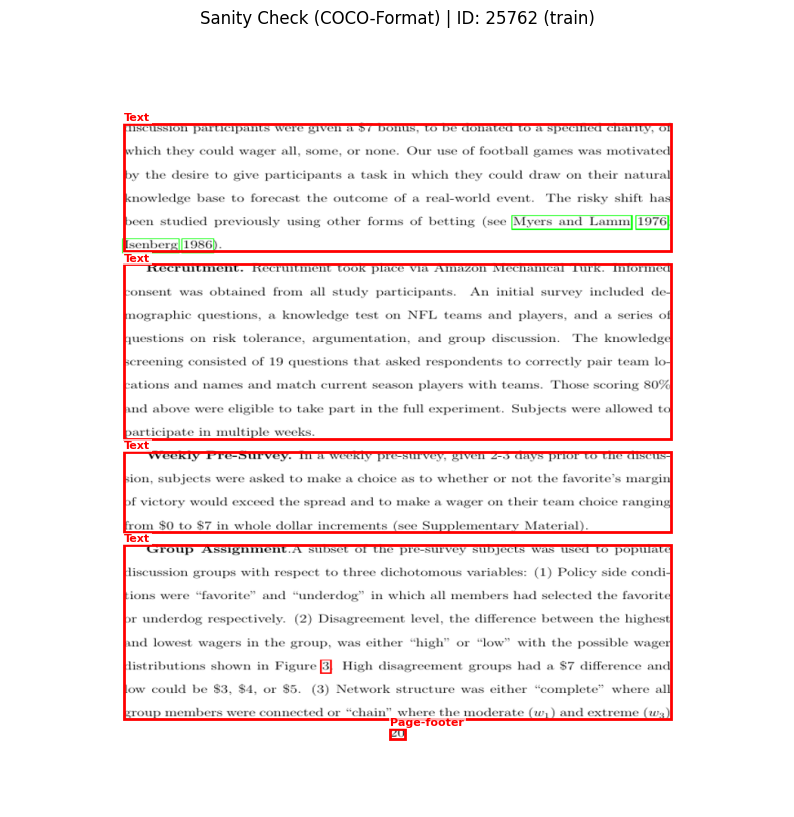

In [11]:
import json
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# PFADE ANPASSEN
SUBSET_DIR = ".data"
SPLIT = "train"  # Welchen Split willst du prüfen? (train, val oder test)

JSON_PATH = f"{SUBSET_DIR}/labels//labels_coco_{SPLIT}.json"
IMAGES_DIR = f"{SUBSET_DIR}/images/{SPLIT}"

# 1. Gekürztes JSON laden
with open(JSON_PATH, 'r') as f:
    coco_data = json.load(f)

# Mappings für die Visualisierung aufbauen
cat_id_to_name = {c['id']: c['name'] for c in coco_data['categories']}

# Wir wählen ein zufälliges Bild aus den tatsächlich im JSON registrierten Bildern
random_img_info = random.choice(coco_data['images'])
target_img_id = random_img_info['id']
img_file_name = f"{target_img_id}.png"
img_path = os.path.join(IMAGES_DIR, img_file_name)

print(f"Prüfe Bild-ID: {target_img_id}")
print(f"Dokumenten-Kategorie: {random_img_info.get('doc_category')}")

# 2. Prüfen, ob das Bild auch physisch im Ordner existiert
if not os.path.exists(img_path):
    print(f"FEHLER: Bilddatei {img_file_name} wurde nicht im Ordner {IMAGES_DIR} gefunden!")
    exit()
else:
    print("-> Bilddatei physisch vorhanden. Überprüfe Bounding Boxen...")

# 3. Alle Annotations filtern, die zu dieser Bild-ID gehören
img_annotations = [ann for ann in coco_data['annotations'] if ann['image_id'] == target_img_id]
print(f"-> {len(img_annotations)} Bounding Boxen im JSON für dieses Bild gefunden.")

# 4. Visuelle Validierung via Matplotlib
img = Image.open(img_path)
fig, ax = plt.subplots(figsize=(10, 12))
ax.imshow(img)

# Jede Box auf das Bild zeichnen
for ann in img_annotations:
    # COCO Format: [x_min, y_min, width, height] (in absoluten Pixeln)
    x, y, w, h = ann['bbox']
    cat_name = cat_id_to_name[ann['category_id']]
    
    # Rechteck zeichnen (Rand rot, transparent innen)
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    
    # Label-Text über die Box setzen
    plt.text(x, y - 4, cat_name, color='red', fontsize=8, weight='bold', 
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

plt.title(f"Sanity Check (COCO-Format) | ID: {target_img_id} ({SPLIT})")
plt.axis('off')

# Anzeige des Plots
plt.show()

## Training YOLO

## Training RT-DETR